In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [20]:
df = pd.read_csv("../data/processed/loan_risk_dataset_clean.csv")
df.head()

,Unnamed: 0,CustomerID,Age,Gender,MaritalStatus,Education,Occupation,EmploymentYears,AnnualIncome,MonthlyExpenses,...,MissedEMIs,BankBalance,PropertyValue,Dependents,Region,CityTier,PreviousDefaults,FraudFlag,CustomerSegment,LoanApproved
0,0,112424.0,36.0,Male,Single,PostGraduate,Salaried,25.0,6114208.0,190034.0,...,3.0,79209.0,46730799.0,4.0,East,Tier3,1.0,No,Regular,No
1,1,108271.0,25.0,Female,Single,HighSchool,SelfEmployed,30.0,4487423.0,24602.0,...,2.0,517042.0,15261353.0,0.0,West,Tier2,1.0,No,Regular,Yes
2,2,122724.0,32.0,Male,Single,Graduate,SelfEmployed,8.0,7493921.0,60028.0,...,4.0,1956071.0,39629890.0,4.0,North,Tier1,0.0,No,Regular,Yes
3,3,112573.0,30.0,Female,Married,Graduate,Student,35.0,4152555.0,187520.0,...,3.0,912949.0,14425719.0,0.0,East,Tier3,2.0,No,Regular,Yes
4,4,112098.0,41.0,Female,Single,Graduate,Business,36.0,7929802.0,199257.0,...,3.0,998835.0,43000549.0,4.0,North,Tier2,2.0,No,Regular,No


In [21]:
df = df.drop(columns=[
    "CustomerID",
    "FraudFlag",
    "CustomerSegment"
], errors="ignore")

In [22]:
categorical_cols = df.select_dtypes(
    include=["object", "string"]
).columns

print("Categorical Columns:")
print(list(categorical_cols))

Categorical Columns:
['Gender', 'MaritalStatus', 'Education', 'Occupation', 'LoanPurpose', 'Region', 'CityTier', 'LoanApproved']


In [23]:
label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

In [24]:
df.head()

,Unnamed: 0,Age,Gender,MaritalStatus,Education,Occupation,EmploymentYears,AnnualIncome,MonthlyExpenses,Savings,...,ATMWithdrawals,LatePayments,MissedEMIs,BankBalance,PropertyValue,Dependents,Region,CityTier,PreviousDefaults,LoanApproved
0,0,36.0,1,2,3,2,25.0,6114208.0,190034.0,4591940.0,...,19.0,8.0,3.0,79209.0,46730799.0,4.0,0,2,1.0,0
1,1,25.0,0,2,1,3,30.0,4487423.0,24602.0,8884145.0,...,11.0,6.0,2.0,517042.0,15261353.0,0.0,3,1,1.0,1
2,2,32.0,1,2,0,3,8.0,7493921.0,60028.0,4163611.0,...,16.0,1.0,4.0,1956071.0,39629890.0,4.0,1,0,0.0,1
3,3,30.0,0,1,0,4,35.0,4152555.0,187520.0,9707012.0,...,0.0,1.0,3.0,912949.0,14425719.0,0.0,0,2,2.0,1
4,4,41.0,0,2,0,0,36.0,7929802.0,199257.0,53335.0,...,11.0,10.0,3.0,998835.0,43000549.0,4.0,1,1,2.0,0


In [25]:
X = df.drop(columns=["LoanApproved"])

y = df["LoanApproved"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (25600, 31)
y Shape : (25600,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (20480, 31)
Testing Data  : (5120, 31)


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [28]:
X_train_scaled = scaler.fit_transform(X_train)

In [29]:
X_test_scaled = scaler.transform(X_test)

In [30]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),
    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
}

In [31]:
scaled_models = [
    "Logistic Regression",
    "KNN",
    "SVM"
]

In [32]:
results = []

trained_models = {}

for name, model in models.items():

    print("Training :", name)

    if name in scaled_models:

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        y_probability = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

        y_probability = model.predict_proba(
            X_test
        )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": roc_auc
    })

    trained_models[name] = model

Training :

 Logistic Regression
Training : Decision Tree
Training : Random Forest
Training : KNN
Training : Naive Bayes
Training : SVM


C:\Users\Pranavraj\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training : AdaBoost
Training : Extra Trees


In [33]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.985156,0.985302,0.994701,0.989979,0.998438
1,AdaBoost,0.985156,0.990972,0.988871,0.989920,0.999339
2,Decision Tree,0.982617,0.985507,0.990991,0.988242,0.975065
3,Extra Trees,0.941406,0.928677,0.997085,0.961666,0.985697
4,SVM,0.886719,0.908440,0.941176,0.924518,0.942563
5,Logistic Regression,0.874805,0.902596,0.930578,0.916373,0.933602
6,KNN,0.811523,0.831641,0.933227,0.879511,0.827550
7,Naive Bayes,0.728906,0.736425,0.984632,0.842630,0.651391


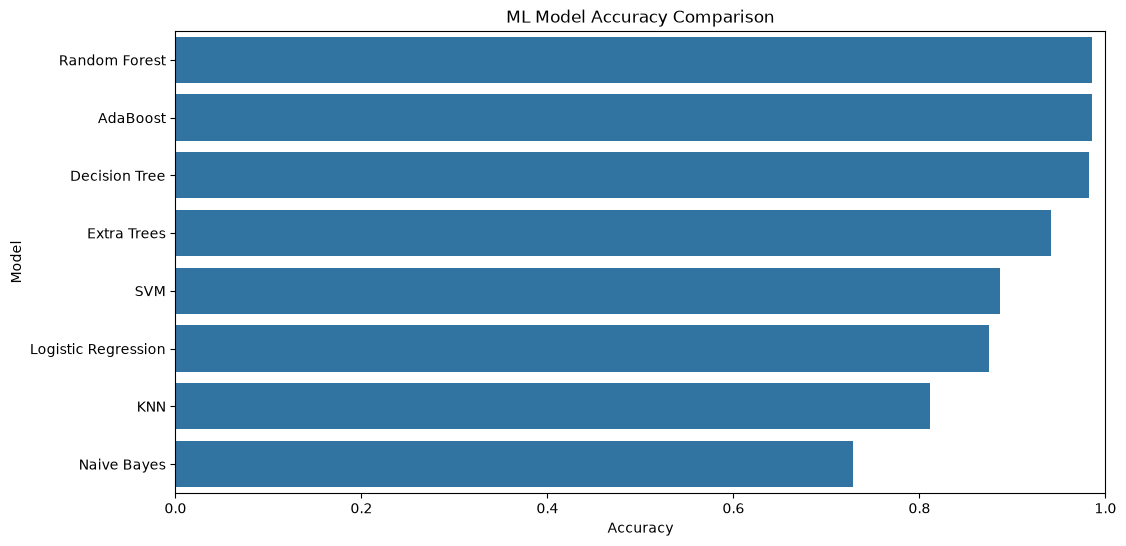

In [34]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("ML Model Accuracy Comparison")

plt.xlabel("Accuracy")

plt.ylabel("Model")

plt.xlim(0, 1)

plt.show()

In [35]:
best_model_name = results_df.loc[
    0,
    "Model"
]

best_model = trained_models[
    best_model_name
]

print("Best Model :", best_model_name)

print(
    "Best Accuracy :",
    results_df.loc[0, "Accuracy"]
)

Best Model : Random Forest
Best Accuracy : 0.98515625
